In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [2]:
df = pd.read_csv('tiktok_dataset.csv', na_values=['#N/A'])

In [3]:
print(df.isnull().sum())

#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64


In [4]:

# Clean Datasets (df_clean)
# Dropping rows missing the target variable or critical information
df_clean = df.dropna(subset=['claim_status']).copy()

print(df_clean.isnull().sum())

#                           0
claim_status                0
video_id                    0
video_duration_sec          0
video_transcription_text    0
verified_status             0
author_ban_status           0
video_view_count            0
video_like_count            0
video_share_count           0
video_download_count        0
video_comment_count         0
dtype: int64


In [5]:
df_clean.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19084.000000,1.908400e+04,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9542.500000,5.624840e+09,32.423811,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5509.220604,2.537030e+09,16.226470,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4771.750000,3.425100e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9542.500000,5.609500e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14313.250000,7.840823e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19084.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


In [6]:
# Outlier Removal (Capping at the 99th percentile)
views_threshold = df_clean['video_view_count'].quantile(0.99)
likes_threshold = df_clean['video_like_count'].quantile(0.99)
df_99 = df_clean[(df_clean['video_view_count'] <= views_threshold) & 
                 (df_clean['video_like_count'] <= likes_threshold)].copy()

In [7]:
df_99.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,18733.000000,1.873300e+04,18733.000000,18733.000000,18733.000000,18733.000000,18733.000000,18733.000000
mean,9632.587946,5.625888e+09,32.388352,241473.244221,77667.800566,15425.247691,968.411787,323.122938
std,5507.945190,2.536415e+09,16.217057,310895.330991,122933.754984,29562.562961,1845.710325,737.527361
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4868.000000,3.427892e+09,18.000000,4861.000000,787.000000,111.000000,7.000000,1.000000
50%,9718.000000,5.614814e+09,32.000000,9760.000000,3126.000000,660.000000,42.000000,9.000000
75%,14401.000000,7.838840e+09,46.000000,481256.000000,114807.000000,16644.000000,1071.000000,265.000000
max,19084.000000,9.999873e+09,60.000000,980704.000000,535932.000000,204814.000000,13142.000000,7767.000000


C:\Users\herma\AppData\Local\Temp\ipykernel_32336\1299366186.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='claim_status', palette='viridis')


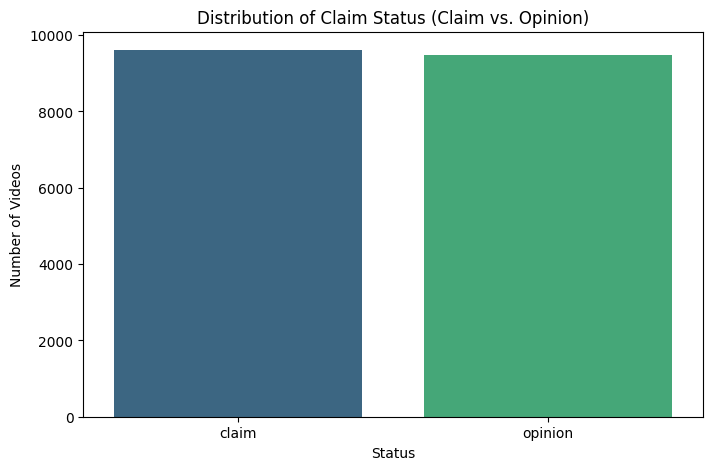

C:\Users\herma\AppData\Local\Temp\ipykernel_32336\1299366186.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='claim_status', y='video_duration_sec', palette='pastel')


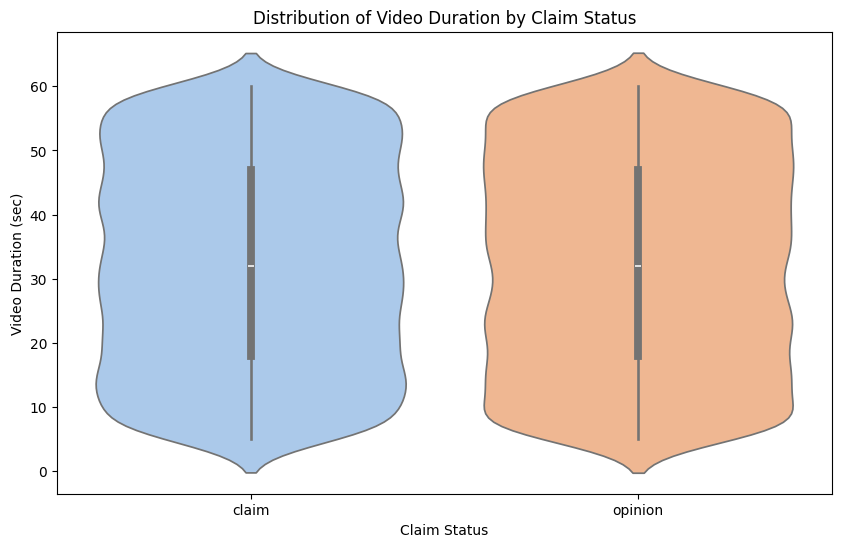

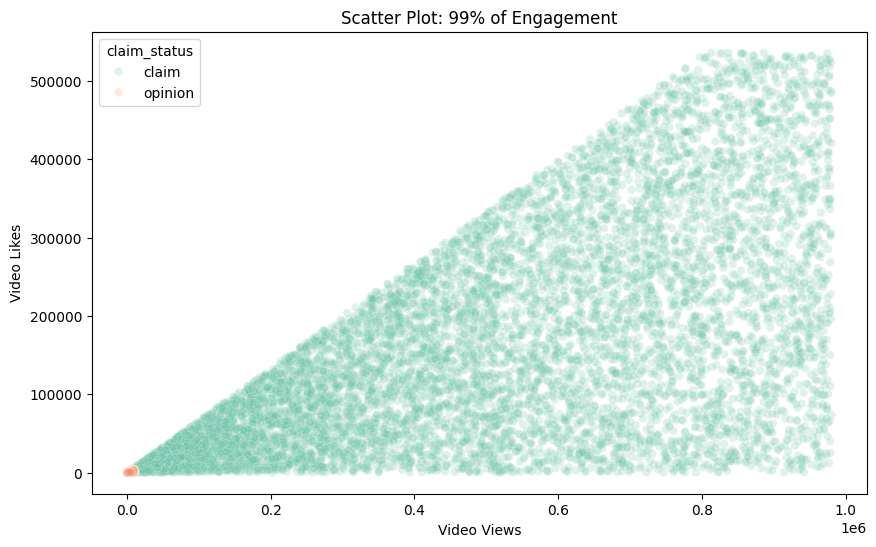

In [8]:
#Claim vs Video Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='claim_status', palette='viridis')
plt.title('Distribution of Claim Status (Claim vs. Opinion)')
plt.ylabel('Number of Videos')
plt.xlabel('Status')
plt.show()

#Claim vs Opinion Video Duration Violin Plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='claim_status', y='video_duration_sec', palette='pastel')
plt.title('Distribution of Video Duration by Claim Status')
plt.xlabel('Claim Status')
plt.ylabel('Video Duration (sec)')
plt.show()

#Video Engagement Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_99, x='video_view_count', y='video_like_count', 
                hue='claim_status', alpha=0.2, palette='Set2')
plt.title('Scatter Plot: 99% of Engagement')
plt.xlabel('Video Views')
plt.ylabel('Video Likes')
plt.show()

In [9]:
# Hypothesis Testing (Independent Samples T-Test)
# Isolate view counts for claims and opinions
claims_views = df_99[df_99['claim_status'] == 'claim']['video_view_count']
opinions_views = df_99[df_99['claim_status'] == 'opinion']['video_view_count']

print(f"Claim Videos Mean View Count: {claims_views.mean()}")
print(f"Opinion Videos Mean View Count: {opinions_views.mean()}")
print(f"Claim Videos Sample Size: {claims_views.count()}")
print(f"Opinion Videos Sample Size: {opinions_views.count()}")



# Perform Welch's T-Test
t_stat, p_value = stats.ttest_ind(claims_views, opinions_views, equal_var=False)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value}")
if p_value < 0.05:
    print("Conclusion: Reject H0. The difference in views is statistically significant.")
else:
    print("Conclusion: Fail to reject H0. No statistically significant difference.")



Claim Videos Mean View Count: 483585.5171221778
Opinion Videos Mean View Count: 4956.43224989447
Claim Videos Sample Size: 9257
Opinion Videos Sample Size: 9476
T-statistic: 163.1046
P-value: 0.0
Conclusion: Reject H0. The difference in views is statistically significant.


In [ ]:
# Predictive Modeling & Three-Way Split (70/15/15)
print("PREDICTIVE MODELING")
# Feature Engineering: Creating new high-signal clues inside df_99
df_99['target_claim'] = np.where(df_99['claim_status'] == 'claim', 1, 0)

# Aggregating interaction parameters into a unified engagement rate clue
df_99['engagement_rate'] = (df_99['video_like_count'] + 
                             df_99['video_share_count'] + 
                             df_99['video_download_count'] + 
                             df_99['video_comment_count']) / df_99['video_view_count']

# Handle infinite values or zeros safely to prevent pipeline breakdown
df_99 = df_99.replace([np.inf, -np.inf], np.nan).dropna(subset=['engagement_rate'])
df_99['log_views'] = np.log1p(df_99['video_view_count'])

# Define our feature inputs (X) and expected targets (y)
X = df_99[['video_duration_sec', 'engagement_rate', 'log_views']]
y = df_99['target_claim']

# Splitting data into 70% Train, 15% Val, 15% Test
# 70% for Training, leave a 30% temporary holdout pool
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Split the 30% into 15% Validation and 15% Testing subsets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Three Way Validation Split:")
print(f" Training Split Data (70%): {X_train.shape[0]} rows")
print(f" Validation Split Data (15%): {X_val.shape[0]} rows (to check  Overfitting)")
print(f" Testing Split Data (15%): {X_test.shape[0]} rows (Final Validation)\n")

# Train the logistic regression engine on the 70% training pool
model = LogisticRegression()
model.fit(X_train, y_train)

print("Model Coefficients:")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f" Feature: {feature:<20} | Coefficient: {coef:.4f}")

PREDICTIVE MODELING
Three Way Validation Split:
 Training Split Data (70%): 13113 rows
 Validation Split Data (15%): 2810 rows (to check  Overfitting)
 Testing Split Data (15%): 2810 rows (Final Validation)

Model Coefficients:
 Feature: video_duration_sec   | Coefficient: 0.0096
 Feature: engagement_rate      | Coefficient: 2.8472
 Feature: log_views            | Coefficient: 4.5119


MODEL EVALUATION
Validation Sub-Dataset Accuracy: 99.11%
Final Test Sub-Dataset Accuracy: 98.90%

Final Test Macro-Averaged F1-Score: 98.89%
Final Test Specific F1-Score for Claims (Class 1): 98.85%

Final Test Performance Report Matrix:
              precision    recall  f1-score   support

 Opinion (0)       0.98      1.00      0.99      1449
   Claim (1)       1.00      0.98      0.99      1361

    accuracy                           0.99      2810
   macro avg       0.99      0.99      0.99      2810
weighted avg       0.99      0.99      0.99      2810



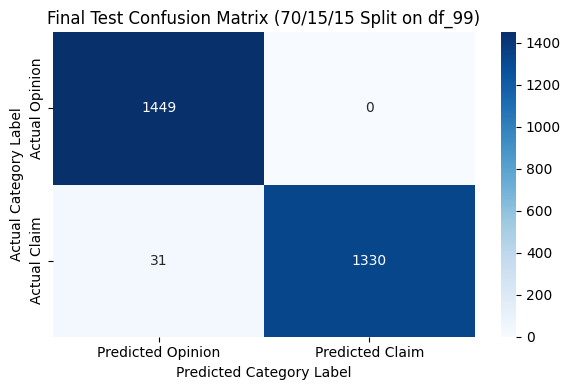

In [ ]:
# Double Evaluation Strategy (Val vs Test)
print("MODEL EVALUATION")

# Check validation performance
y_val_pred = model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Sub-Dataset Accuracy: {val_accuracy * 100:.2f}%")

# Run predictions on final Test Dataset
y_test_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Final Test Sub-Dataset Accuracy: {test_accuracy * 100:.2f}%\n")

# Standalone isolated F1-Score calculations for explicit evaluation report text
macro_f1 = f1_score(y_test, y_test_pred, average='macro')
print(f"Final Test Macro-Averaged F1-Score: {macro_f1 * 100:.2f}%")

claim_f1 = f1_score(y_test, y_test_pred, pos_label=1)
print(f"Final Test Specific F1-Score for Claims (Class 1): {claim_f1 * 100:.2f}%\n")

# Detailed matrix output based exclusively on the final Test data subset
print("Final Test Performance Report Matrix:")
print(classification_report(y_test, y_test_pred, target_names=['Opinion (0)', 'Claim (1)']))

# Build and present the graphical Confusion Matrix Heatmap for the Test subset
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Opinion', 'Predicted Claim'],
            yticklabels=['Actual Opinion', 'Actual Claim'])
plt.title('Final Test Confusion Matrix (70/15/15 Split on df_99)')
plt.ylabel('Actual Category Label')
plt.xlabel('Predicted Category Label')
plt.tight_layout()
plt.show()

Random Forest Test Result
Accuracy: 99.47%
Macro F1-Score: 99.47%

Classification Report:
              precision    recall  f1-score   support

 Opinion (0)       0.99      1.00      0.99      1449
   Claim (1)       1.00      0.99      0.99      1361

    accuracy                           0.99      2810
   macro avg       0.99      0.99      0.99      2810
weighted avg       0.99      0.99      0.99      2810



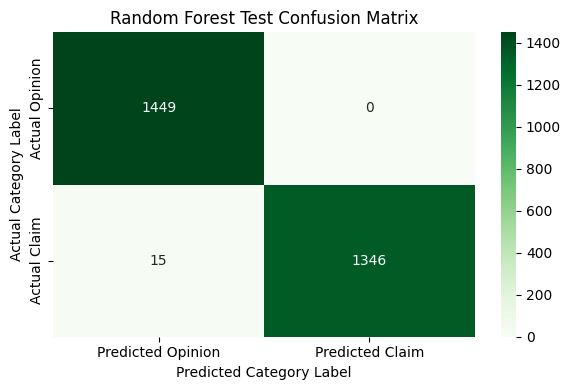

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predict on the test subset
y_test_pred_rf = rf_model.predict(X_test)

# Output evaluation metrics
print("Random Forest Test Result")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_rf) * 100:.2f}%")
print(f"Macro F1-Score: {f1_score(y_test, y_test_pred_rf, average='macro') * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_rf, target_names=['Opinion (0)', 'Claim (1)']))

# Generate and display the Confusion Matrix Heatmap
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Predicted Opinion', 'Predicted Claim'],
            yticklabels=['Actual Opinion', 'Actual Claim'])
plt.title('Random Forest Test Confusion Matrix')
plt.ylabel('Actual Category Label')
plt.xlabel('Predicted Category Label')
plt.tight_layout()
plt.show()